In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import joblib

In [2]:
path = r"C:/Users/DAKSH/Downloads/customer-churn-prediction-advanced/models/processed_data.pkl"
X_train, X_test, y_train, y_test = joblib.load(path)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8276, 19)
Test shape: (1409, 19)


In [35]:
#Initialize Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),    
    "KNN": KNeighborsClassifier()
}

In [36]:
#Train Models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print("\n",name)
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))


 Logistic Regression
Accuracy: 0.758694109297374
              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1036
           1       0.53      0.83      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409


 Random Forest
Accuracy: 0.7885024840312278
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1036
           1       0.60      0.60      0.60       373

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409


 SVM
Accuracy: 0.7601135557132718
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1036
           1       0.54      0.71      0.61       373

    accuracy                           0.76      140

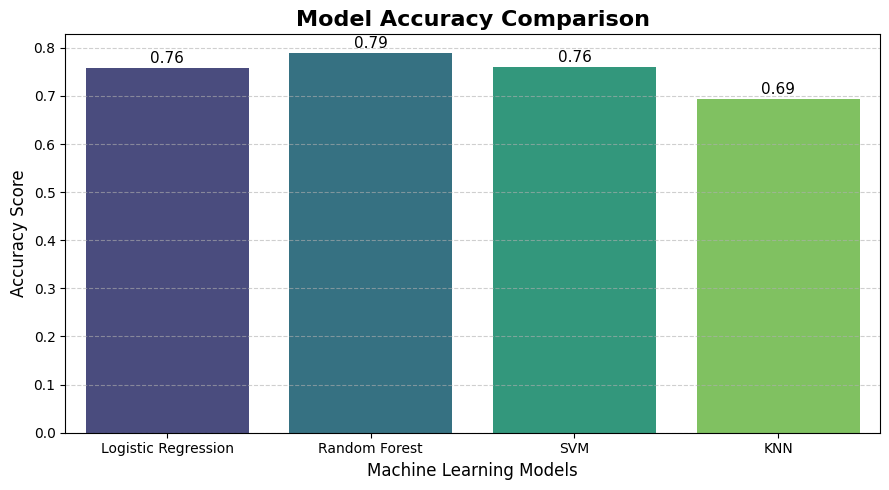

In [37]:
#Model Accuracy Comparison Chart
plt.figure(figsize=(9,5))
models = list(results.keys())
scores = list(results.values())
ax = sns.barplot(x=models,y=scores,hue=models,palette="viridis",legend=False)
plt.title("Model Accuracy Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
# add value labels
for i, v in enumerate(scores):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [38]:
#Train Best Model (Random Forest)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

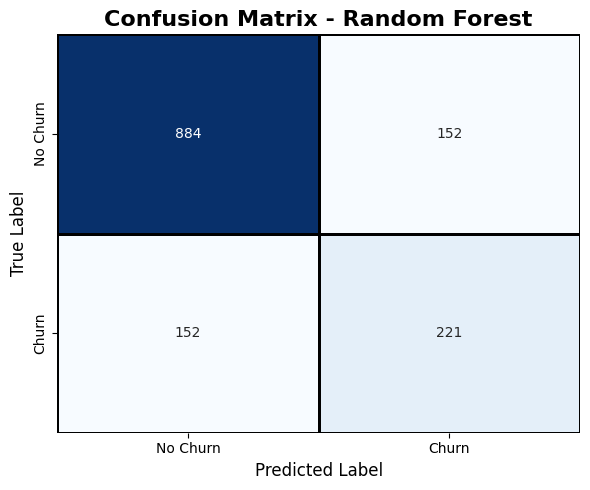

In [39]:
#Confusion Matrix
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6,5))
ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    cbar=False
)
ax.set_title("Confusion Matrix - Random Forest", fontsize=16, fontweight="bold")
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_xticklabels(["No Churn", "Churn"])
ax.set_yticklabels(["No Churn", "Churn"])
plt.tight_layout()
plt.show()

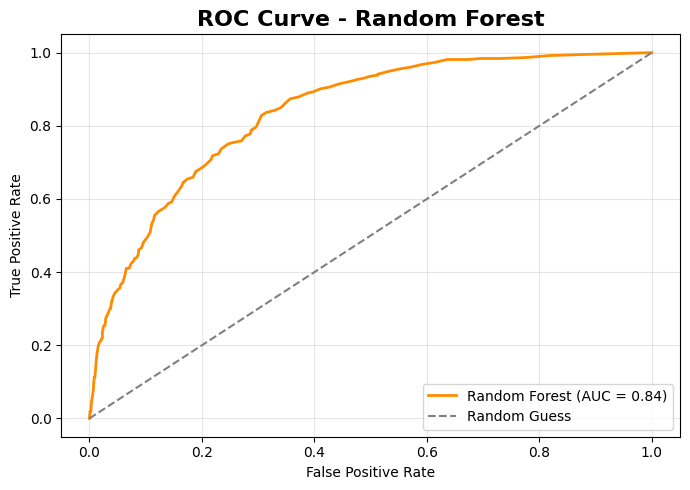

In [40]:
#ROC Curve
rf_probs = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, rf_probs)
auc_score = roc_auc_score(y_test, rf_probs)
plt.figure(figsize=(7,5))
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    linewidth=2,
    label=f"Random Forest (AUC = {auc_score:.2f})"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Guess"
)
plt.title("ROC Curve - Random Forest", fontsize=16, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
#AUC Score
roc_auc_score(y_test, rf_probs)

0.8359474468723798

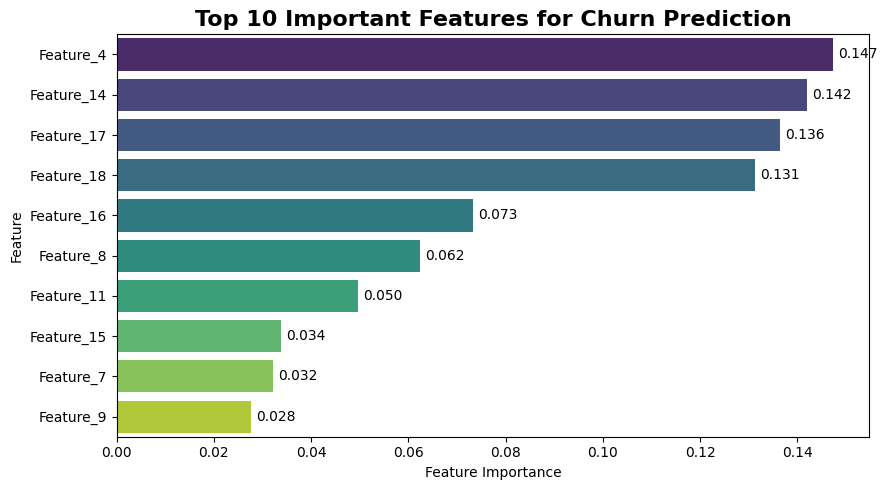

In [42]:
#Feature Importance (Very Important)
plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)
for i, v in enumerate(importance_df.head(10)["Importance"]):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center")
plt.title(
    "Top 10 Important Features for Churn Prediction",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

In [50]:
#Precision / Recall Table
#Initialize Models
metrics = []
for name, model in models.items():
    # train model
    model.fit(X_train, y_train)
    # prediction
    preds = model.predict(X_test)
    metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)
    })
metrics_df = pd.DataFrame(metrics)
metrics_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.758694,0.528205,0.828418,0.645094
2,SVM,0.760114,0.535211,0.713137,0.611494
1,Random Forest,0.784244,0.590551,0.603217,0.596817
3,KNN,0.694109,0.452303,0.737265,0.560652


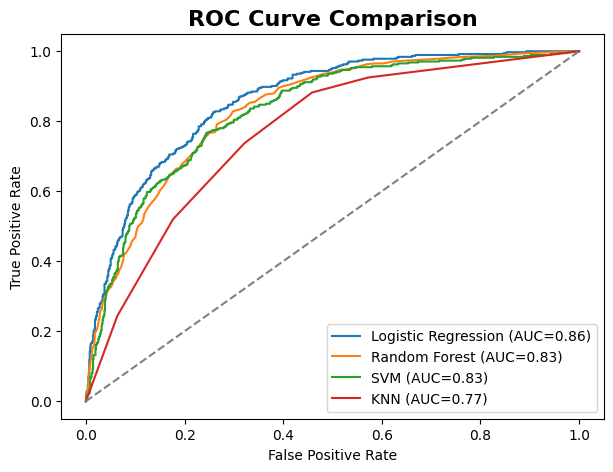

In [51]:
#ROC Curve Comparison (Powerful Plot)
plt.figure(figsize=(7,5))
for name, model in models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
plt.plot([0,1],[0,1],'--', color="gray")
plt.title("ROC Curve Comparison", fontsize=16, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [34]:
#Best Model Selection
best_model = max(results, key=results.get)

print("Best Model:", best_model)
print("Accuracy:", results[best_model])

Best Model: Random Forest
Accuracy: 0.7920511000709723


In [52]:
import joblib
model_path = r"C:/Users/DAKSH/Downloads/customer-churn-prediction-advanced/models/churn_model.pkl"
joblib.dump(rf, model_path)
print("Model saved successfully!")


Model saved successfully!
